# Text, Embeddings, and a Baseline — NLTK Movie Reviews

The first lesson with real data: 2,000 actual film reviews, half positive and half
negative. Three things have to happen before any model can look at them — text becomes
integers, integers become learned vectors, and a ragged batch becomes a rectangle.

Then we build the simplest classifier that works at all: **embed every token, average
the vectors, and put a single linear layer on top**. It is called a *bag of embeddings*,
it has no architecture to speak of, and it will reach around 80% test accuracy. That
number matters more than the model does — every architecture in the rest of the book is
measured against it.

## Step 1: Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import nltk
import random
from collections import Counter

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', device)

## Key Concept: Devices and `.to(device)`

PyTorch can run computations on the **CPU** or a **GPU** (NVIDIA CUDA or
Apple Silicon MPS). Moving a tensor or model to a device means its data and
computations live there.

```python
device = torch.device('mps' if torch.backends.mps.is_available()
                       else 'cuda' if torch.cuda.is_available()
                       else 'cpu')

model = MyModel().to(device)   # moves all weight tensors to device
X = X.to(device)               # moves input data to the same device
```

**Rule:** model and data must be on the *same* device — mixing them raises
a `RuntimeError`. Call `.to(device)` on both.

> 📖 [PyTorch — CUDA semantics](https://pytorch.org/docs/stable/notes/cuda.html)


## Key Concept: `Dataset` and `DataLoader`

`DataLoader` handles batching, shuffling, and parallel data loading so your
training loop stays simple.

```python
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X_train, y_train)   # pairs inputs with labels
loader  = DataLoader(dataset,
                     batch_size=64,
                     shuffle=True)           # reshuffles every epoch

for Xb, yb in loader:                       # Xb: (64, ...) one mini-batch
    ...
```

Key parameters:
- `batch_size` — number of samples per gradient update
- `shuffle=True` — randomize order each epoch (always use for training)
- `num_workers` — background processes for loading (set to 2-4 on most machines)

> 📖 [PyTorch — Writing a Custom Dataset](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html)


## Step 2: Load the Movie Reviews Corpus

NLTK's `movie_reviews` has 2 000 documents already split by `pos` / `neg` categories. Each document is pre-tokenized into a list of words.

In [ ]:
from nltk.corpus import movie_reviews

random.seed(42)
docs = [(movie_reviews.words(fid), cat)
        for cat in movie_reviews.categories()
        for fid in movie_reviews.fileids(cat)]
random.shuffle(docs)

print(f'Total reviews : {len(docs)}')
print(f'Categories    : {movie_reviews.categories()}')
print(f'First 10 words: {list(docs[0][0])[:10]}')
print(f'Label         : {docs[0][1]}')

## Key Concept: Word Embeddings

Raw text cannot be fed directly into a neural network — we need numeric
representations.

**One-hot encoding** (naïve): word `i` → a sparse `(vocab_size,)` vector
with a single 1 at position `i`. Problems: enormous dimensionality (10 000+),
no notion of similarity ("film" and "movie" are orthogonal), sparse gradients.

**Learned embeddings** (`nn.Embedding`): a trainable lookup table of shape
`(vocab_size, embed_dim)`. Each word maps to a dense `embed_dim`-dimensional
vector. Trained end-to-end, embeddings organize themselves so semantically
similar words cluster together in embedding space.

```python
nn.Embedding(vocab_size, embed_dim, padding_idx=0)
# (batch_size, seq_len)  →  (batch_size, seq_len, embed_dim)
```

`padding_idx=0`: the `<PAD>` token's embedding is permanently zeroed out so
padding never contributes to the model's signal.

**Why not pre-trained embeddings (GloVe, Word2Vec)?**
They'd likely improve accuracy here. We train from scratch so the mechanism
is transparent and the notebook is self-contained.


## Step 3: Build a Vocabulary

Cap at `MAX_VOCAB = 10 000` most frequent words. Reserve index 0 for `<PAD>` and index 1 for `<UNK>` (unknown words).

In [ ]:
MAX_VOCAB = 10000
MAX_LEN   = 600    # reviews average 792 words — see the note below

# TODO: count all lowercase words across all docs
all_words = ...
freq      = Counter(all_words)

# TODO: build vocab dict {'<PAD>':0, '<UNK>':1, word:idx, ...}
vocab = {'<PAD>': 0, '<UNK>': 1}
# add the top MAX_VOCAB-2 words

print(f'Vocab size: {len(vocab)}')
print(f'Top 10   : {freq.most_common(10)}')

## Step 4: Encode Reviews and Pad/Truncate

Map each word to its vocab index (1 = UNK if unseen). Pad with 0s or truncate so every review is exactly `MAX_LEN` words.

In [ ]:
def encode(words, vocab, max_len):
    # TODO: convert words to indices; truncate/pad to max_len
    tokens = ...
    return tokens

X_data = [encode(ws, vocab, MAX_LEN) for ws, _ in docs]
y_data = [1 if label == 'pos' else 0 for _, label in docs]

X_tensor = torch.tensor(X_data, dtype=torch.long)
y_tensor = torch.tensor(y_data, dtype=torch.float32)
print('X:', X_tensor.shape, '  y:', y_tensor.shape)

## Step 5: Train / Test Split and DataLoaders

In [ ]:
split = int(0.8 * len(X_tensor))
X_train, X_test = X_tensor[:split], X_tensor[split:]
y_train, y_test = y_tensor[:split], y_tensor[split:]

# TODO: wrap in TensorDataset and create DataLoaders
# batch_size=32, shuffle train set
train_loader = ...
test_loader  = ...
print(f'Train batches: {len(train_loader)}  Test batches: {len(test_loader)}')

## Key Concept: turning a sequence into one vector

The embedding layer gives you a matrix — one row per token, `(B, L, embed_dim)`. A
classifier needs one vector per review, `(B, embed_dim)`. Something has to collapse the
length axis, and the cheapest thing that works is the mean.

```
Input:        (B, 600)        word indices, one row per review
Embedding:    (B, 600, 64)    one 64-d vector per token
Masked mean:  (B, 64)         average over REAL tokens only
Dropout:      (B, 64)
Linear:       (B, 1)          one logit per review
```

**Why the mask.** Every review is padded to 600 tokens. A 40-word review is 560 tokens
of `<PAD>`, so a plain `.mean(dim=1)` lets padding contribute 80% of the answer — and it
damages short reviews more than long ones, which means the bug correlates with length
rather than just adding noise. Multiply by the mask, sum, and divide by the true length.

**What averaging costs.** Addition is commutative, so `"the acting saved a terrible
script"` and `"a terrible script saved the acting"` produce the *identical* vector. The
model cannot distinguish them even in principle. That is not a weakness to tune away —
it is the ceiling, and every later lesson is a different answer to it.

## Step 6: Define the model

In [ ]:
class SentimentBaseline(nn.Module):
    """Embed, average over the real tokens, classify. That is the whole model."""

    def __init__(self, vocab_size, embed_dim=64, pad_idx=0):
        super().__init__()
        # A lookup table of shape (vocab_size, embed_dim). padding_idx pins that row
        # to zero and keeps it there — it never receives a gradient.
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(embed_dim, 1)
        self.pad_idx = pad_idx

    def forward(self, x):                       # x: (B, L) word indices
        # TODO:
        #   1. mask   = (x != self.pad_idx).unsqueeze(-1).float()   -> (B, L, 1)
        #   2. e      = self.embedding(x)                           -> (B, L, E)
        #   3. pooled = (e * mask).sum(1) / mask.sum(1).clamp_min(1.0)
        #      (sum over REAL tokens, divide by how many there were)
        #   4. return sigmoid(self.fc(self.dropout(pooled))).squeeze(1)
        pass


model = SentimentBaseline(len(vocab)).to(device)
print(model)

### Concept Check: the baseline

**Q1.** Why `(e * mask).sum(1) / mask.sum(1)` instead of `e.mean(1)`?

*(Answers are in `solution.ipynb`.)*

In [ ]:
# Q1:
# Q2:
# Q3:


## Key Concept: factor the training loop

You are about to write a training loop for the third time. Write it once, as two
functions, and every later lesson can reuse them unchanged:

```python
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()                      # dropout ON, batchnorm updating
    total = 0.0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        loss = criterion(model(Xb), yb)
        optimizer.zero_grad()          # gradients accumulate; clear them first
        loss.backward()
        optimizer.step()
        total += loss.item() * Xb.size(0)
    return total / len(loader.dataset)

@torch.no_grad()                       # no graph, no gradients, less memory
def evaluate(model, loader, criterion, device):
    model.eval()                       # dropout OFF — this is not optional
    total, correct = 0.0, 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        out = model(Xb)
        total += criterion(out, yb).item() * Xb.size(0)
        correct += ((out >= 0.5).float() == yb).sum().item()
    return total / len(loader.dataset), correct / len(loader.dataset)
```

Three things this buys beyond tidiness. `model.train()` and `model.eval()` are stated
exactly once each, so you cannot forget one. Weighting by `Xb.size(0)` makes the epoch
loss correct even when the last batch is short — a plain mean over batches is subtly
wrong. And having `evaluate` separate means measuring validation loss costs one line, so
you will actually do it.

## Key Concept: learning rate schedules

A constant learning rate is a compromise: large enough to make progress early is usually
too large to settle later. A schedule resolves it.

```python
optimizer = optim.Adam(model.parameters(), lr=3e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

for epoch in range(EPOCHS):
    train_one_epoch(...)
    scheduler.step()          # once per EPOCH here — see below
```

**Step it in the right place.** `CosineAnnealingLR` with `T_max=EPOCHS` expects one call
per epoch. A per-batch scheduler (`OneCycleLR`, or warmup) expects one call per *batch*,
and `T_max` must then be `EPOCHS * len(loader)`. Stepping an epoch scheduler per batch
decays the rate to nothing within the first epoch, and the symptom is a loss that drops
promisingly and then simply stops moving.

**Warmup** — starting near zero and ramping up over the first few hundred steps — matters
for transformers specifically, and for the reason given in the chapter on residual
connections: early in training the residual stream is the only well-conditioned path, and
a large first step can push a layer somewhere it never recovers from.

## Key Concept: keep the best epoch, not the last

Validation loss usually reaches its minimum before training ends, and then rises while
training loss keeps falling. If you keep the weights you happen to have at the end, you
keep an overfitted model and throw away the good one you already had.

```python
best = float("inf")
for epoch in range(EPOCHS):
    train_one_epoch(...)
    val_loss, val_acc = evaluate(...)
    if val_loss < best:
        best = val_loss
        torch.save(model.state_dict(), "best.pt")     # weights only, not the object

model.load_state_dict(torch.load("best.pt"))          # restore before reporting anything
```

Save the `state_dict`, not the model. Pickling the model object ties the file to your
class definitions and import paths, so it breaks the moment you rename anything; a
`state_dict` is just a dictionary of tensors and loads into any equivalent architecture.

## Step 7: Train the Model

In [ ]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)
train_losses = []

for epoch in range(30):
    model.train()
    total_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)  # Xb: (32,200)  yb: (32,)

        # Forward: embedding → conv → pool → linear → sigmoid. Graph is recorded.
        out  = model(Xb).squeeze()  # (32,1) → (32,) to match yb's shape for BCELoss

        loss = criterion(out, yb)   # BCELoss: per-sample binary cross-entropy, then mean

        optimizer.zero_grad()       # clear last batch's gradients — PyTorch accumulates
        loss.backward()             # backprop through conv layers, embeddings, everything
        optimizer.step()            # Adam updates each weight with its own adaptive lr

        total_loss += loss.item()   # detach from graph; just a Python float now
    avg = total_loss / len(train_loader)
    train_losses.append(avg)
    print(f'Epoch {epoch+1:2d} | Loss: {avg:.4f}')

## Step 8: Evaluate on Test Set

In [ ]:
model.eval()
correct = total = 0
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        # TODO: get predictions, count correct
        ...
print(f'Test accuracy: {correct/total*100:.1f}%')

### Concept Check: Regularization & Evaluation

**Q1.** `nn.Dropout(0.2)` zeros 50% of activations randomly during training.
How does this prevent overfitting? Why is it *disabled* during `model.eval()`?

**Q2.** If train accuracy is 95% but test accuracy is 65%, what is happening
and what are three techniques you could use to close the gap?

**Q3.** The model uses `nn.BCELoss` with a sigmoid output.
`nn.BCEWithLogitsLoss` (raw logit, no sigmoid) is numerically more stable.
Why? When would numerical stability matter in practice?

In [ ]:
# Q1:
# Q2:
# Q3:


## Step 9: Predict on a New Review

In [ ]:
def predict(text, model, vocab, max_len, device):
    model.eval()
    with torch.no_grad():
        tokens = [vocab.get(w.lower(), 1) for w in text.split()][:max_len]
        tokens += [0] * (max_len - len(tokens))
        x = torch.tensor([tokens], dtype=torch.long, device=device)
        prob = model(x).item()
        return f'positive ({prob:.2f})' if prob >= 0.5 else f'negative ({prob:.2f})'

print(predict('This film was absolutely wonderful and moving', model, vocab, MAX_LEN, device))
print(predict('Terrible waste of time, boring and predictable', model, vocab, MAX_LEN, device))

## Step 10: Where the parameters live

In [ ]:
import matplotlib.pyplot as plt

# Almost the entire model is a lookup table that performs no computation.
sizes = [(n, p.numel()) for n, p in model.named_parameters()]
sizes.sort(key=lambda kv: -kv[1])
names = [n for n, _ in sizes]
counts = [c for _, c in sizes]

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(names[::-1], counts[::-1], color=["#74b9ff"] + ["#b2bec3"] * (len(names) - 1))
ax.set_xscale("log")
ax.set_xlabel("parameters (log scale)")
ax.set_title("Where the parameters are: it is the lookup table")
for i, c in enumerate(counts[::-1]):
    ax.text(c, i, f"  {c:,}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

print("The pooling step is absent from this chart because it has no parameters.")
print("Anything you do to improve this model has to touch the embedding.")

## Step 11: Plot Training Loss

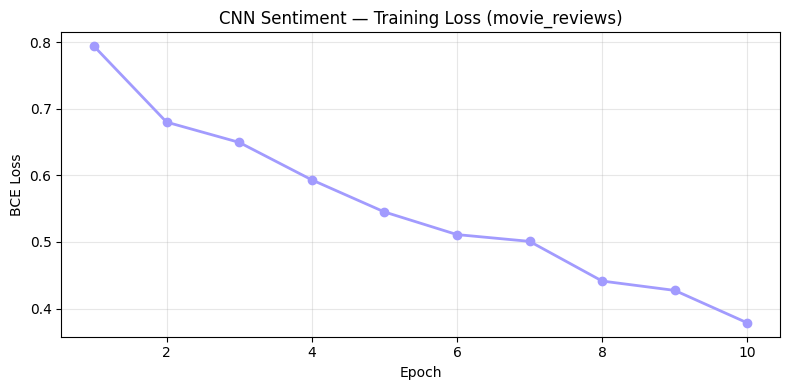

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, 'o-', color='#a29bfe', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Baseline — Training Loss (movie_reviews)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()